# SpaceX Falcon 9 lunar impact — crater detection with the NASA-IBM Lunar Foundation Model

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NASA-IMPACT/NASA-IBM-Lunar-Foundation-Model/blob/main/examples/crater_detection_inference.ipynb)

The **NASA-IBM Lunar Foundation Model** is pretrained on multi-instrument lunar data. A shared pretrained
backbone lets each downstream task be fine-tuned with relatively little labeled data; the task here is
**crater detection**, a Faster R-CNN head on Lunar Reconnaissance Orbiter Narrow Angle Camera (NAC)
imagery:

```
ni_lfm_v1_base ViT (patch size 8, 1-channel NAC)
  -> SelectIndices [2, 5, 8, 11] -> ReshapeTokensToImage
  -> MultilayerSimpleFeaturePyramid -> FPN
  -> Faster R-CNN head (Background / Crater)
```

This notebook applies that fine-tuned detector to a real event: a SpaceX Falcon 9 rocket body impacted
the lunar farside near Einstein crater, and LRO images of the same area before and after. Running the
detector on the before/after NAC pair isolates the freshly formed impact crater, a concrete test that a
foundation-model detector transfers to a surface feature that did not exist during training. A final
section runs the same model on a labeled benchmark tile so its detections can be checked against
ground-truth crater boxes.

**Pipeline:** install the package · download the fine-tuned checkpoint and backbone config · run
inference on the before/after images · draw the impact figure · validate on a benchmark sample.

**Runtime:** GPU optional, the two 256×256 images run in seconds on CPU. The first run downloads ~1.75 GB
of weights, so it takes a few minutes.

**Image source:** the before/after NAC pair is from CNN's coverage of NASA's images of the SpaceX rocket
lunar impact (2026-08-18,
[edition.cnn.com](https://edition.cnn.com/2026/08/18/science/nasa-images-spacex-rocket-moon-collision)).
Underlying data: NASA LRO Narrow Angle Camera (LROC; NASA/GSFC/Arizona State University).


## 1 · Install the package

Installs `ni_lfm` + `terratorch_integration` and dependencies, which support **Python 3.11–3.12**. The
first install pulls in PyTorch and other large dependencies, so it can take a few minutes.

**On Colab:** select a matching runtime **before running this cell**, Runtime → Change runtime type →
Runtime version → `2026.07` (Python 3.12) or `2025.07` (Python 3.11). pip may upgrade NumPy/torch under
the running kernel, so the cell **restarts the runtime once** to load the fresh builds. When it returns,
**re-run this cell** and continue.

**Locally:** use a Python 3.11 or 3.12 environment, and install the package into it *before* launching
Jupyter so nothing is upgraded mid-session (then this cell just confirms the import):

```bash
conda create -n ni-lfm python=3.12 -y && conda activate ni-lfm
# or, with venv on a 3.11/3.12 interpreter:  python3.12 -m venv .venv && source .venv/bin/activate
pip install "git+https://github.com/NASA-IMPACT/NASA-IBM-Lunar-Foundation-Model.git"
# or, from a clone of this repo:  pip install -e .
jupyter lab   # then open examples/crater_detection_inference.ipynb
```


In [ ]:
import sys, subprocess, importlib, os

PY = sys.version_info
print("Python:", ".".join(map(str, PY[:3])), "at", sys.executable)
if PY < (3, 11) or PY >= (3, 13):
    raise SystemExit(
        f"Python {PY.major}.{PY.minor} is unsupported; this package needs 3.11 or 3.12. "
        "On Colab, pin a matching runtime (Runtime > Change runtime type > Runtime version > "
        "2026.07 for 3.12, or 2025.07 for 3.11); locally, use a 3.11/3.12 environment. Then re-run."
    )

REPO = "git+https://github.com/NASA-IMPACT/NASA-IBM-Lunar-Foundation-Model.git"
FLAG = "/tmp/.nilfm_restart_guard"

def _import_pkg():
    importlib.invalidate_caches()
    import terratorch_integration, ni_lfm  # noqa: F401
    return terratorch_integration.__file__

# Import-first: if the package is already available (a local env that has it, or a Colab re-run after the
# restart below), skip the install entirely - this also avoids clobbering an editable `pip install -e .`.
try:
    print("\nAlready installed:", _import_pkg())
    if os.path.exists(FLAG):
        os.remove(FLAG)
except Exception:
    if subprocess.run([sys.executable, "-m", "pip", "install", REPO]).returncode != 0:
        raise SystemExit("pip install failed - read pip's error above; re-run this cell if it was transient.")
    # Confirm the fresh install imports. If pip upgraded numpy/torch under the running kernel, restart once
    # (guarded by a flag file so it cannot loop) so the fresh builds load, then re-run this cell.
    try:
        print("\nInstall verified:", _import_pkg())
        if os.path.exists(FLAG):
            os.remove(FLAG)
    except Exception as e:
        if os.path.exists(FLAG):
            os.remove(FLAG)
            raise SystemExit(f"Still failing to import after a restart: {e.__class__.__name__}: {e}")
        open(FLAG, "w").close()
        print(f"\npip upgraded numpy/torch under the kernel ({e.__class__.__name__}). Restarting once;")
        print("re-run this cell when the runtime returns, then continue.")
        sys.stdout.flush()
        os.kill(os.getpid(), 9)

## 2 · Download weights

Downloads two files from the Hugging Face Hub into its shared cache (`~/.cache/huggingface`); nothing is
written into your working directory.

- Fine-tuned crater checkpoint `NAC_ni_lfm_ps8_s44.ckpt` (~1.75 GB): the full fine-tune behind the
  published crater-detection results.
- Backbone config `backbone/config.yaml` (a few KB): describes the ViT so the model can be rebuilt.


In [ ]:
import os
from huggingface_hub import hf_hub_download

CKPT = hf_hub_download(
    repo_id="nasa-ibm-ai4science/Crater-Detection-NASA-IBM-Lunar-Foundation-Model",
    filename="NAC_ni_lfm_ps8_s44.ckpt",
)

# Only the backbone config is needed - the fine-tuned checkpoint already carries the backbone weights.
BACKBONE_CFG = hf_hub_download(
    repo_id="nasa-ibm-ai4science/NASA-IBM-Lunar-Foundation-Model",
    filename="backbone/config.yaml",
)

print("checkpoint:", os.path.basename(CKPT))
print("backbone config:", os.path.basename(BACKBONE_CFG))

## 3 · Load the before/after images

The two `(256, 256) uint8` NAC crops ship in `examples/spacex_crater/` as lossless grayscale PNGs, so their pixels are
identical to the original arrays. The cell loads them from the repo checkout if present and otherwise
downloads them, so it works both from a clone and on a bare Colab runtime.


In [ ]:
import numpy as np
from pathlib import Path
from urllib.request import urlretrieve
from PIL import Image

RAW_BASE = ("https://raw.githubusercontent.com/NASA-IMPACT/"
            "NASA-IBM-Lunar-Foundation-Model/main/examples/spacex_crater")
IMAGE_FILES = {"pre_256_native": "pre_256_native.png",
               "post_256_native": "post_256_native.png"}

def locate(fn):
    """Find the PNG in a repo checkout (a few likely spots), else download it from the repo."""
    for cand in (fn, f"spacex_crater/{fn}", f"examples/spacex_crater/{fn}"):
        if Path(cand).exists():
            return cand
    try:
        urlretrieve(f"{RAW_BASE}/{fn}", fn)
        print("downloaded", fn)
        return fn
    except Exception as e:
        raise FileNotFoundError(
            f"Could not find or download {fn} ({e}). Run this notebook from a clone of the repo, "
            "or upload the two PNGs (Colab: Files sidebar -> upload) so they sit next to it."
        )

images = {name: np.asarray(Image.open(locate(fn)).convert("L"), dtype=np.uint8)
          for name, fn in IMAGE_FILES.items()}
pre, post = images["pre_256_native"], images["post_256_native"]
for name, arr in images.items():
    print(f"{name:16s} {arr.shape} {arr.dtype}")

## 4 · Load the model and run inference

Build the detector from the backbone config and the fine-tuned checkpoint, normalize each image with the
train-split NAC statistics, and call the wrapped Faster R-CNN. `detect()` is reused in section 6.


In [ ]:
import os, copy
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")  # deterministic CUDA kernels

import numpy as np, torch
import terratorch_integration  # noqa: F401  registers the backbone/necks/task
from terratorch_integration import LunarObjectDetectionTask

NORM_MEAN, NORM_STD = 0.346548, 0.159291   # train-split NAC stats (DN/255)
SCORE_FLOOR = 0.05

# The fine-tuned checkpoint already carries the backbone weights, so point backbone_cfg at the config and
# set backbone_checkpoint_path=None. Read model_args, override those two fields, and let
# load_from_checkpoint restore the fine-tuned weights on top.
_ckpt = torch.load(CKPT, map_location="cpu", weights_only=False)
model_args = copy.deepcopy(_ckpt["hyper_parameters"]["model_args"])
del _ckpt
model_args["backbone_cfg"] = BACKBONE_CFG
model_args["backbone_checkpoint_path"] = None

model = LunarObjectDetectionTask.load_from_checkpoint(
    CKPT, map_location="cpu", model_args=model_args,
).eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
print("model loaded on", device)

def detect(arr):
    """Run the detector on a (256, 256) uint8 NAC array; return detections scoring >= SCORE_FLOOR."""
    img = (arr.astype(np.float32) / 255.0 - NORM_MEAN) / NORM_STD
    tensor = torch.tensor(img).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        preds = model.model(tensor).output[0]
    return [
        {"box": b, "score": s, "label": l}
        for b, s, l in zip(preds["boxes"].cpu().numpy().tolist(),
                           preds["scores"].cpu().numpy().tolist(),
                           preds["labels"].cpu().numpy().tolist())
        if s >= SCORE_FLOOR
    ]

results = {name: detect(arr) for name, arr in images.items()}

## 5 · Before vs. after: the new impact crater

The same patch of terrain, before and after the SpaceX rocket impact.

**Top row:** the raw NAC images; the red box on the post
image marks the newly formed SpaceX crater, absent from the pre-impact image at the same location.

**Bottom row:**
the model's detections, with the impact crater in red.


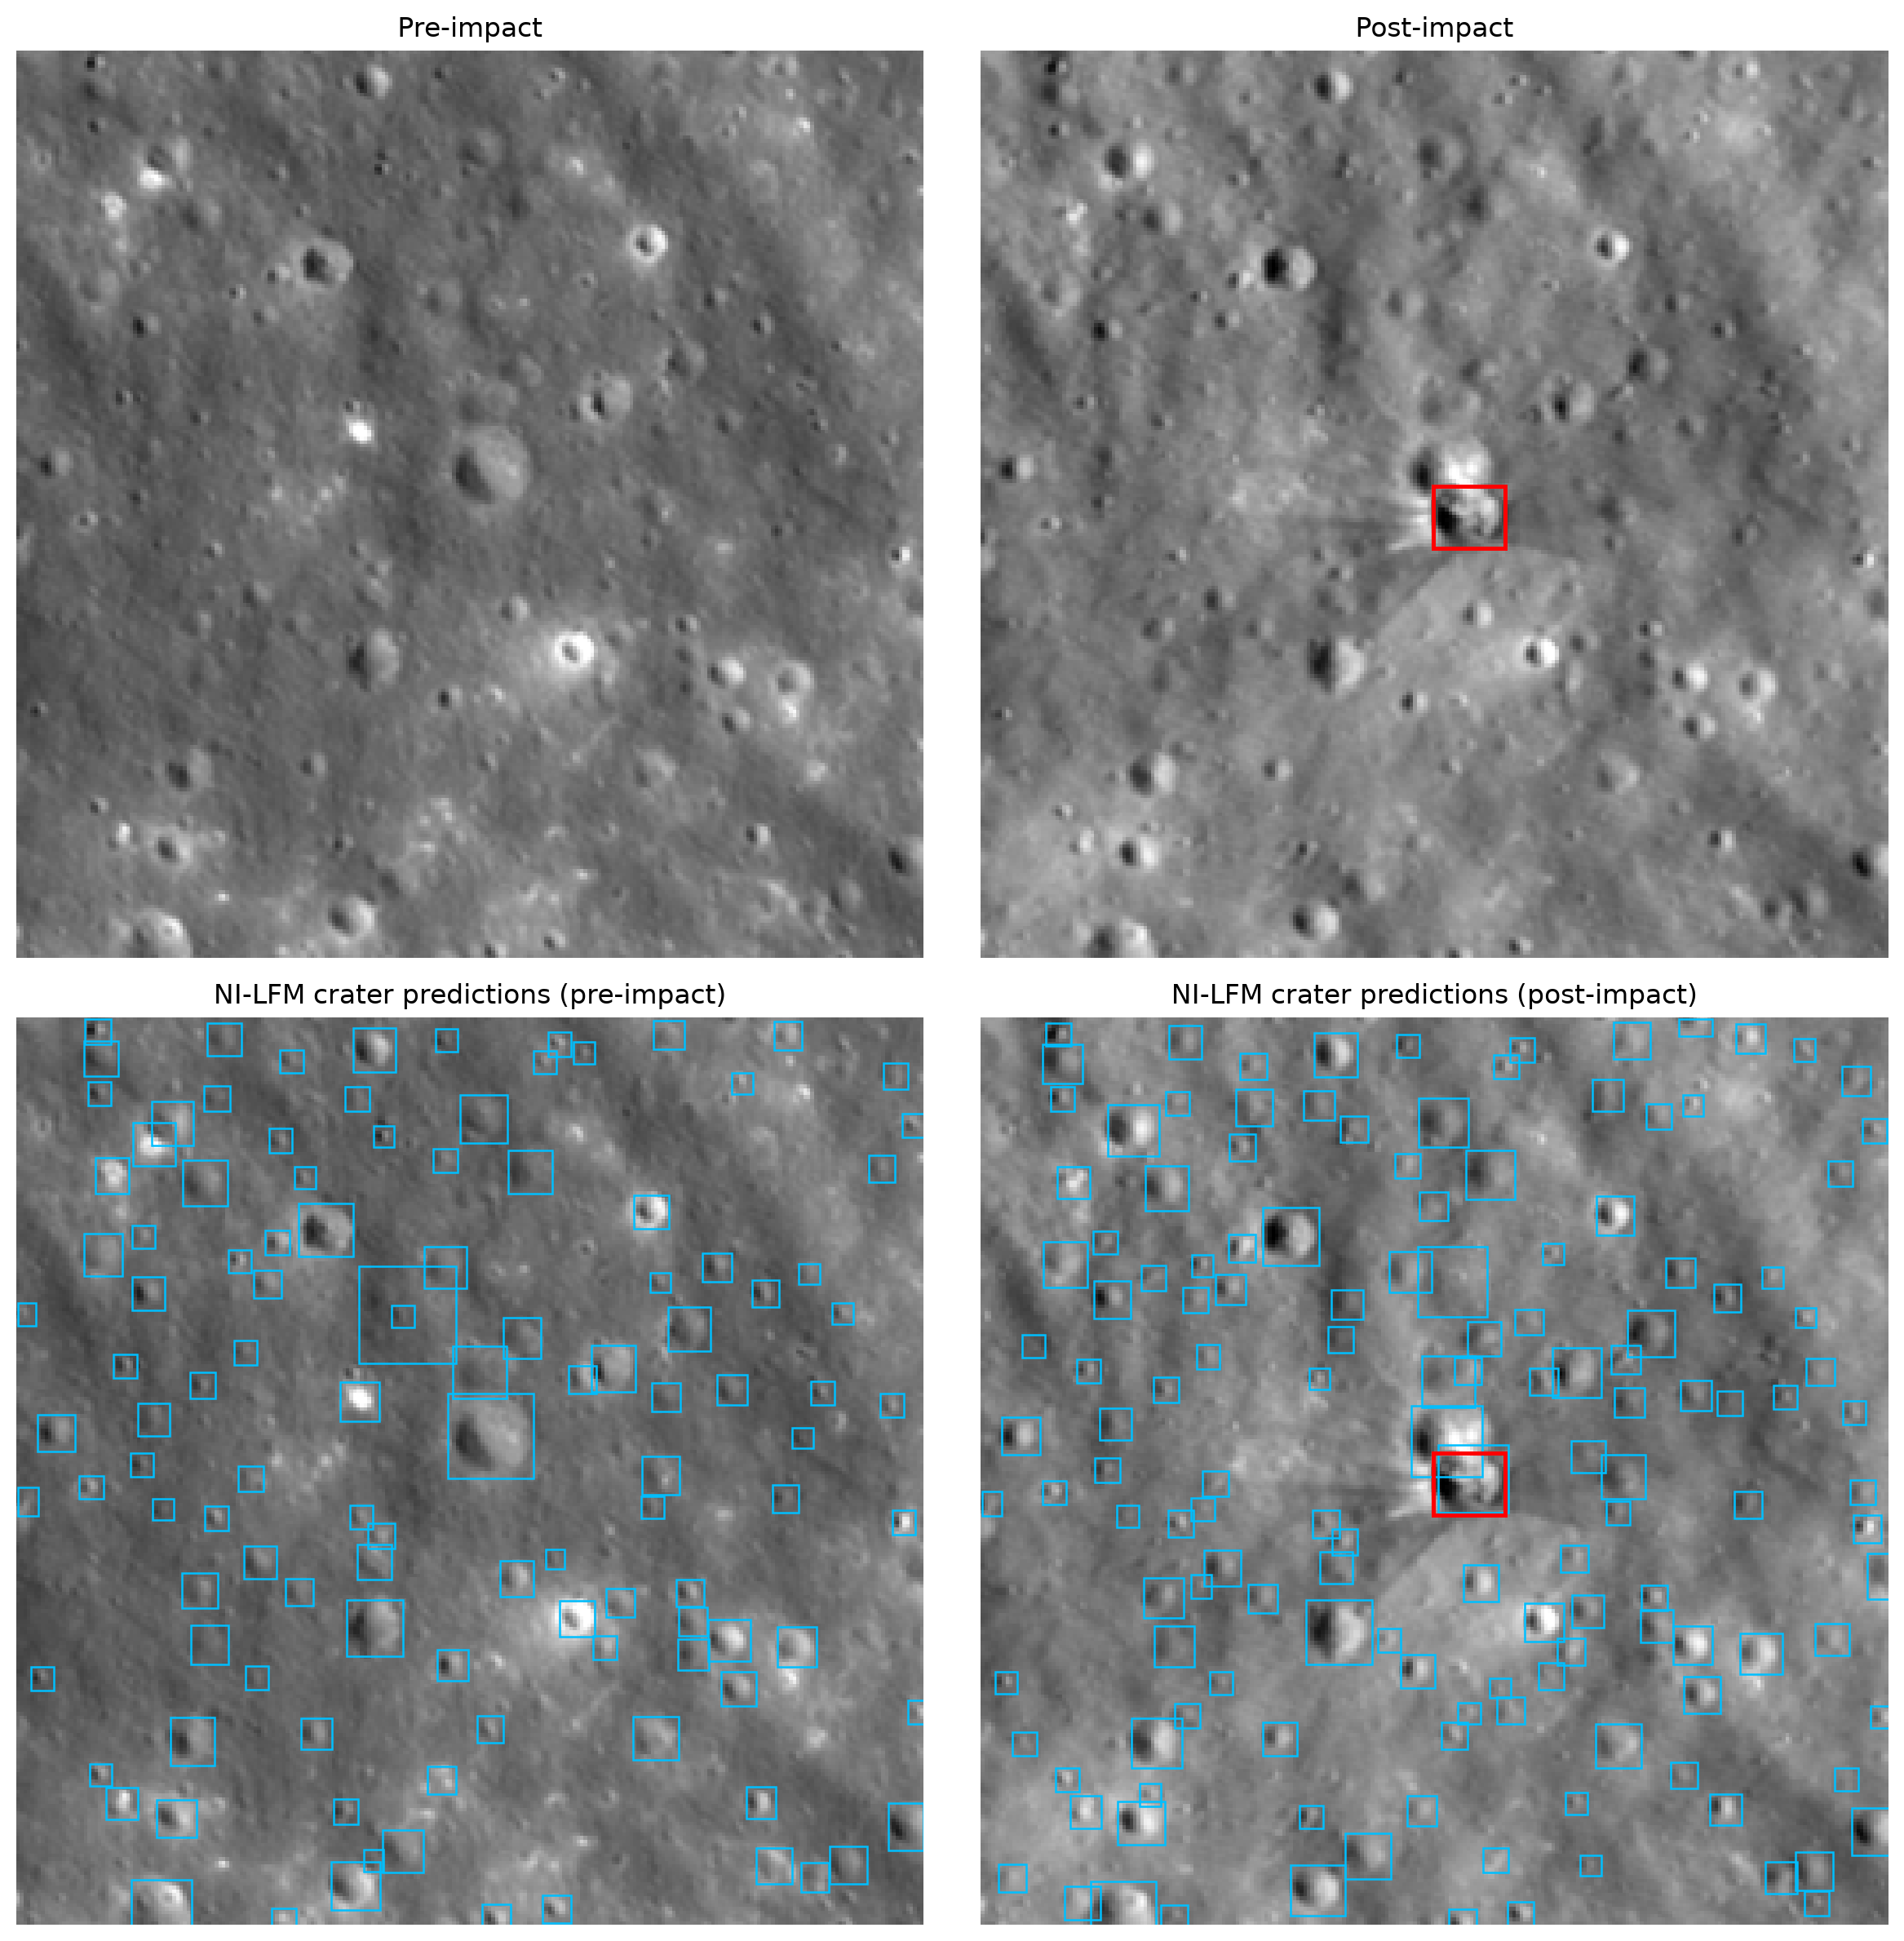

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

SCORE_THRESH = 0.5
MIN_SIZE, MAX_SIZE = 5, 30
COLOR_BOX, COLOR_CRATER = "#00BFFF", "#FF0000"
TARGET_BOX = [127.2, 122.5, 147.5, 140]   # Highlight the newly formed SpaceX impact crater

def keep(d):
    if d["score"] < SCORE_THRESH:
        return False
    w = d["box"][2] - d["box"][0]
    h = d["box"][3] - d["box"][1]
    return MIN_SIZE <= max(w, h) <= MAX_SIZE

def draw(ax, box, color, lw):
    x1, y1, x2, y2 = box
    ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                   linewidth=lw, edgecolor=color, facecolor="none"))

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for col, name in enumerate(["pre_256_native", "post_256_native"]):
    is_post = name == "post_256_native"
    kept = [d for d in results[name] if keep(d)]
    for row in (0, 1):                        # row 0: raw image, row 1: with detections
        ax = axes[row, col]
        ax.imshow(images[name], cmap="gray", vmin=0, vmax=255)
        ax.axis("off")
        if row == 1:
            for d in kept:
                draw(ax, d["box"], COLOR_BOX, 0.9)
        if is_post:                           # mark the new crater in both post panels
            draw(ax, TARGET_BOX, COLOR_CRATER, 1.8)
    axes[0, col].set_title("Post-impact" if is_post else "Pre-impact")
    axes[1, col].set_title(f"NI-LFM crater predictions ({'post' if is_post else 'pre'}-impact)")
plt.tight_layout()
plt.show()

## 6 · Validate on a labeled benchmark tile

The same detector, run on one tile from the test split of the **SOMBench NAC Crater Detection** dataset
([Hugging Face](https://huggingface.co/datasets/nasa-ibm-ai4science/Sombench-NAC-Crater-Detection)), with
its detections (blue) placed beside the ground-truth crater boxes (green). The model recovers most
reference craters and also flags additional plausible craters that are not in the labeled set.


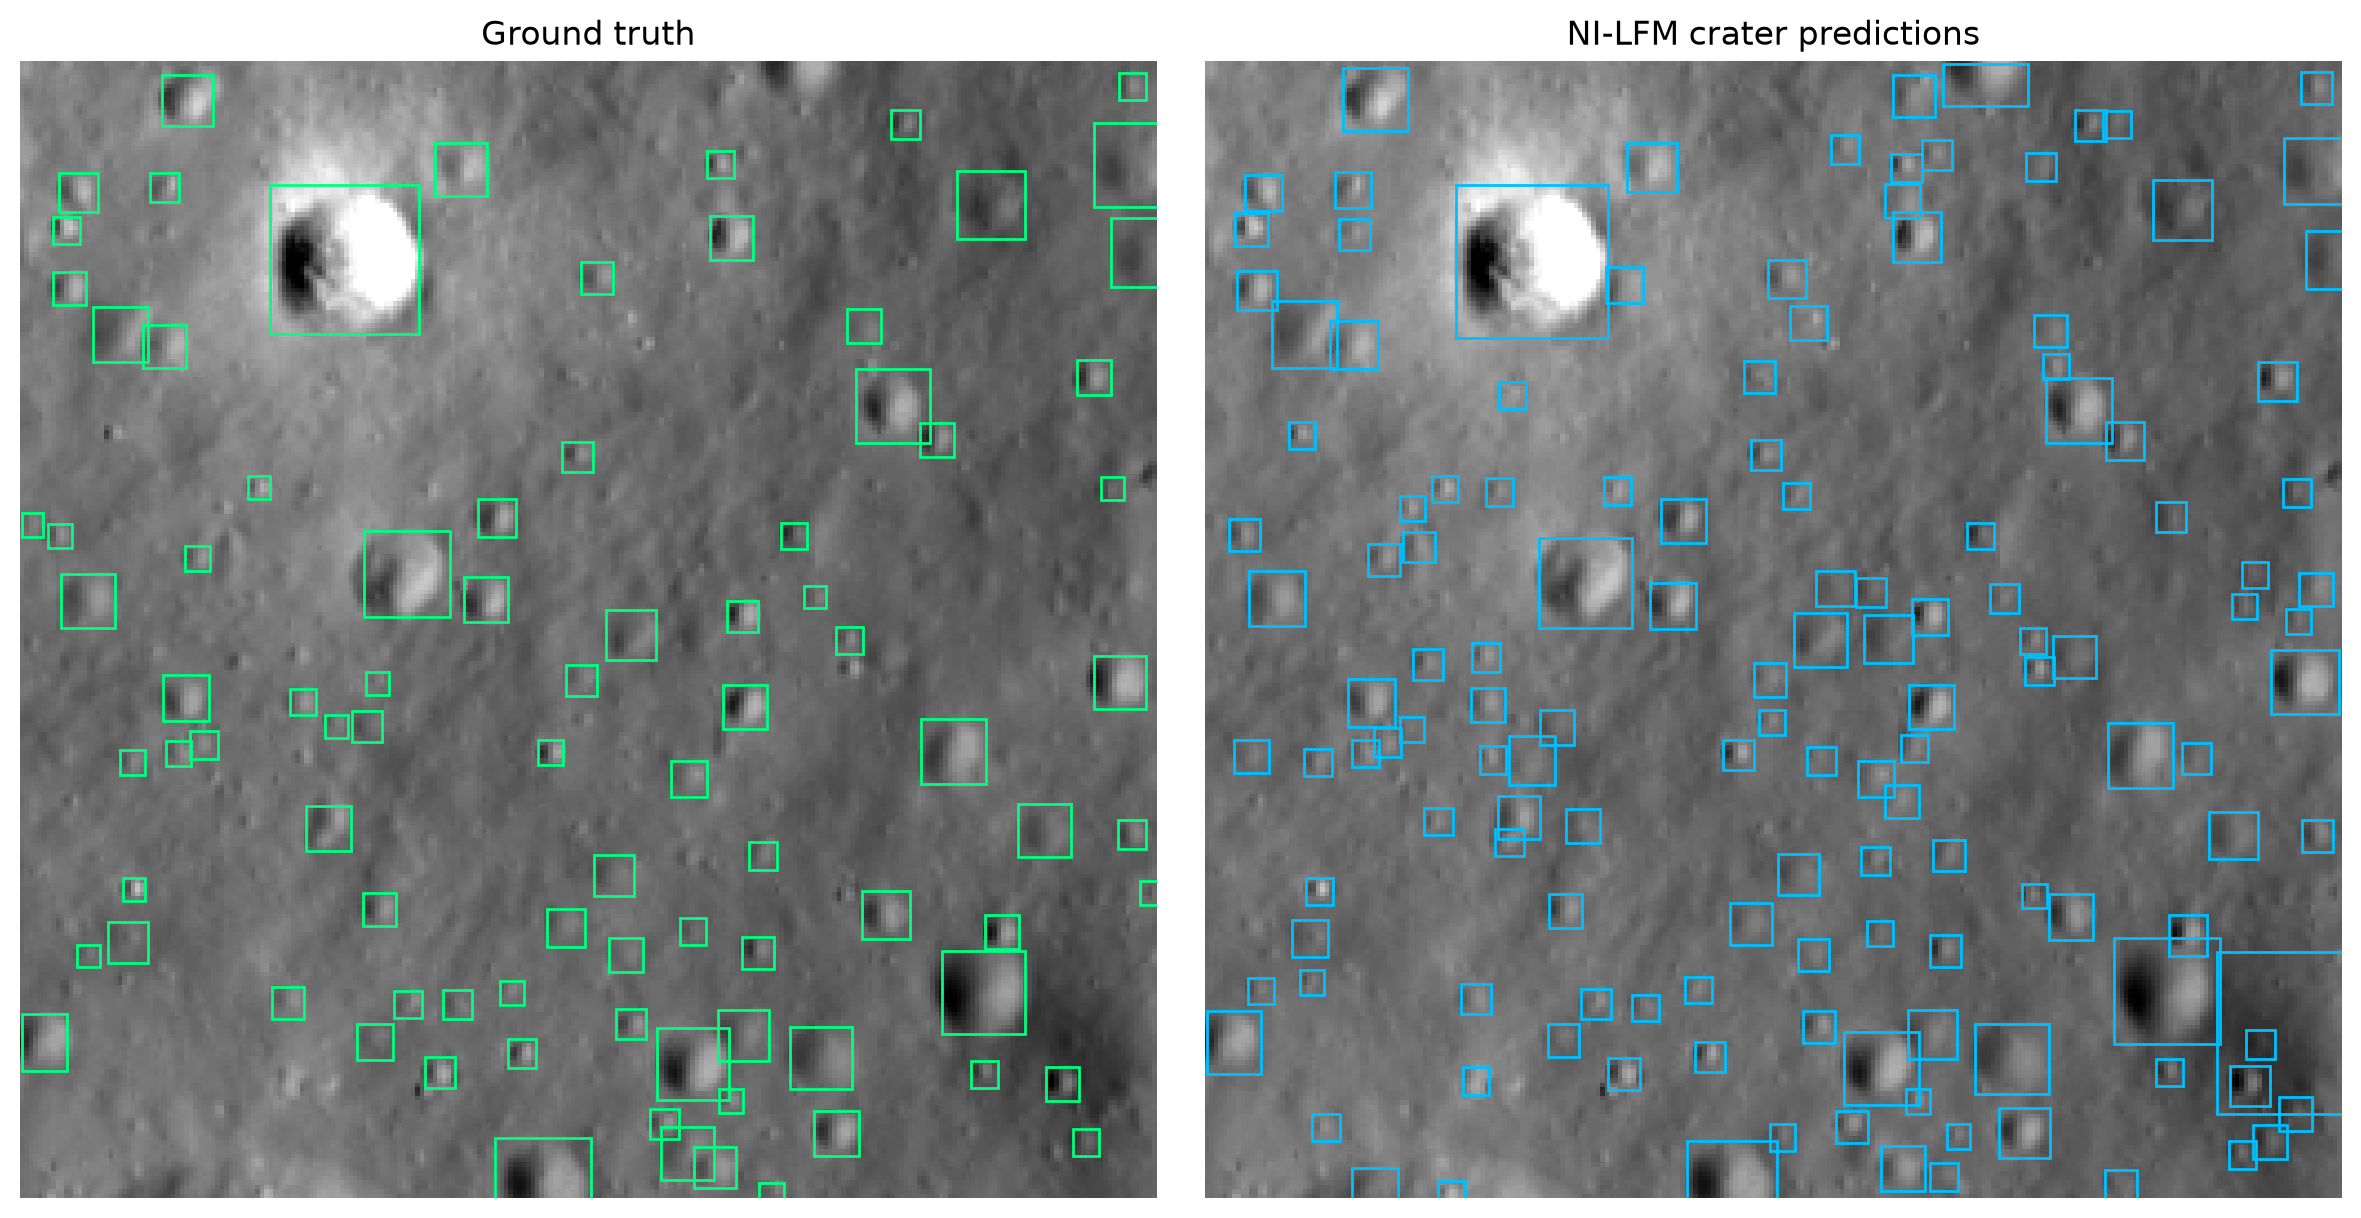

In [ ]:
import json
from huggingface_hub import hf_hub_download

DATASET = "nasa-ibm-ai4science/Sombench-NAC-Crater-Detection"
SAMPLE = "images/NAC_DTM_HLNDPHOTOM2_PHO_E011N1499__standard_box3__r0_c225.npy"

ann = json.load(open(hf_hub_download(DATASET, "annotations_min5px_test.json", repo_type="dataset")))
img_id = next(im["id"] for im in ann["images"] if im["file_name"] == SAMPLE)
gt = [[a["bbox"][0], a["bbox"][1], a["bbox"][0] + a["bbox"][2], a["bbox"][1] + a["bbox"][3]]
      for a in ann["annotations"] if a["image_id"] == img_id]

tile = np.load(hf_hub_download(DATASET, SAMPLE, repo_type="dataset")).astype(np.uint8)
pred = [d["box"] for d in detect(tile) if d["score"] >= SCORE_THRESH]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, title, boxes, color in [
    (axes[0], "Ground truth", gt, "#00FF7F"),
    (axes[1], "NI-LFM crater predictions", pred, "#00BFFF"),
]:
    ax.imshow(tile, cmap="gray", vmin=0, vmax=255)
    ax.axis("off")
    ax.set_title(title)
    for x1, y1, x2, y2 in boxes:
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                       linewidth=1.0, edgecolor=color, facecolor="none"))
plt.tight_layout()
plt.show()

---
**Caveat.** As noted in the release caption, differences in lighting between the two acquisitions affect
the visibility of smaller craters, so the before/after panels are not a clean like-for-like difference.
The newly formed impact crater is the salient, high-confidence feature that appears only in the post image.
